In [39]:
from __future__ import annotations

import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")

from pathlib import Path
import sys

import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ---- Project import ----
# Assumption: notebook lives in project_root/notebooks/ so parents[0] is project_root.
# If your notebook is deeper, change parents[...] accordingly.
PROJECT_ROOT = Path.cwd().resolve().parents[0]
sys.path.insert(0, str(PROJECT_ROOT))

import trace_st as tst  # noqa: E402

# Global reproducibility for synthetic data generation
GLOBAL_SEED = 11
rng = np.random.default_rng(GLOBAL_SEED)


In [40]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [41]:
from tigramite.independence_tests.robust_parcorr import RobustParCorr
from tigramite.independence_tests.parcorr import ParCorr
from tigramite.independence_tests.gpdc import GPDC
from tigramite.independence_tests.cmiknn import CMIknn

# Case 1

## Functions

In [46]:
def gaussian_blob(y2d, x2d, y0, x0, sig_y=6.0, sig_x=10.0, amp=1.0):
    """
    2D Gaussian blob centered at (y0, x0) in Cartesian space.

    Important decision:
    - Cartesian coordinates use ordinary Euclidean distance.
    - No periodic wrapping is applied by default.
    """
    dy = y2d - float(y0)
    dx = x2d - float(x0)

    return amp * np.exp(-0.5 * (dy / sig_y) ** 2 - 0.5 * (dx / sig_x) ** 2)


def advect_centers(y0, x0, vy, vx, T):
    """
    Deterministic trajectory of the blob center in Cartesian space.

    Decision:
    - Constant velocity advection keeps the example interpretable.
    - You can later add time-varying velocity for a harder test.
    """
    centers = np.zeros((T, 2), dtype=float)
    y, x = float(y0), float(x0)

    for t in range(T):
        centers[t] = (y, x)
        y += float(vy)
        x += float(vx)

    return centers


def make_ar1_noise(shape, phi=0.8, sigma=0.1, rng=None, standardize=False):
    """
    Generate AR(1) noise in time independently at each grid point.

    Parameters
    ----------
    shape : tuple
        (T, NY, NX)
    phi : float
        AR(1) coefficient in time. Must satisfy |phi| < 1.
    sigma : float
        Innovation std.
    rng : np.random.Generator
    standardize : bool
        If True, standardize final field to mean 0 and std 1.

    Returns
    -------
    noise : np.ndarray
        AR(1) noise with shape (T, NY, NX)
    """
    if rng is None:
        rng = np.random.default_rng()

    T, NY, NX = shape
    noise = np.zeros(shape, dtype=np.float32)

    # stationary initial condition
    noise[0] = rng.normal(
        0.0,
        sigma / np.sqrt(1.0 - phi**2 + 1e-12),
        size=(NY, NX)
    ).astype(np.float32)

    for t in range(1, T):
        eps = rng.normal(0.0, sigma, size=(NY, NX)).astype(np.float32)
        noise[t] = phi * noise[t - 1] + eps

    if standardize:
        noise = (noise - noise.mean()) / (noise.std() + 1e-12)

    return noise


from scipy.ndimage import gaussian_filter


def make_spatiotemporal_ar1_noise(
    shape,
    phi=0.8,
    sigma=0.1,
    smooth_sigma_y=1.5,
    smooth_sigma_x=1.5,
    rng=None,
    standardize=False
):
    """
    AR(1) in time with spatially smoothed innovations.

    Important decision:
    - In Cartesian toy experiments we use non-periodic boundaries,
      so smoothing uses mode='nearest'.
    """
    if rng is None:
        rng = np.random.default_rng()

    T, NY, NX = shape
    noise = np.zeros(shape, dtype=np.float32)

    eps0 = rng.normal(0.0, sigma, size=(NY, NX)).astype(np.float32)
    eps0 = gaussian_filter(
        eps0,
        sigma=(smooth_sigma_y, smooth_sigma_x),
        mode="nearest"
    )

    noise[0] = eps0 / np.sqrt(1.0 - phi**2 + 1e-12)

    for t in range(1, T):
        eps = rng.normal(0.0, sigma, size=(NY, NX)).astype(np.float32)
        eps = gaussian_filter(
            eps,
            sigma=(smooth_sigma_y, smooth_sigma_x),
            mode="nearest"
        )
        noise[t] = phi * noise[t - 1] + eps

    if standardize:
        noise = (noise - noise.mean()) / (noise.std() + 1e-12)

    return noise

In [47]:
def run_one_track(full_data, params, date_end):
    """
    Single Trace-ST run; returns centers (n_steps, 2) and parents.
    """
    out = tst.trajectory.run_track(
        full_data,
        params,
        date_end=date_end,
        return_debug=True,
        return_cluster_summaries=False,
    )

    centers = np.asarray(out["centers"], dtype=float)
    parents = np.asarray(out["parents"], dtype=int)

    return centers, parents, out

## Create data

In [78]:
# --- Time axis ---
T = 40
time = pd.date_range("2001-01-01", periods=T, freq="D")  # arbitrary, deterministic

# --- Spatial grid (Cartesian) ---
Y_MIN, Y_MAX = 0, 200
X_MIN, X_MAX = 0, 200

NY = 121
NX = 241

ys = np.linspace(Y_MIN, Y_MAX, NY)
xs = np.linspace(X_MIN, X_MAX, NX)

x2d, y2d = np.meshgrid(xs, ys)

print("Grid:", "NY=", NY, "NX=", NX, "x range=", (xs.min(), xs.max()))


# ------------------------------------------------------------
# Toy case: three parent blobs in the same A field
# Higher temporal resolution, same large-scale behavior
# ------------------------------------------------------------

import copy
import numpy as np

def linear_centers_to_event(event_y, event_x, vy, vx, T):
    """
    Build a linear trajectory whose final point is (event_y, event_x).
    """
    centers = np.zeros((T, 2), dtype=float)
    centers[-1] = (event_y, event_x)

    for t in range(T - 2, -1, -1):
        centers[t, 0] = centers[t + 1, 0] - vy
        centers[t, 1] = centers[t + 1, 1] - vx

    return centers


def bezier_centers(start, control1, control2, end, T):
    """
    Smooth curved trajectory using a cubic Bezier curve.
    All points are given as (y, x).
    """
    u = np.linspace(0.0, 1.0, T)
    centers = np.zeros((T, 2), dtype=float)

    p0 = np.asarray(start, dtype=float)
    p1 = np.asarray(control1, dtype=float)
    p2 = np.asarray(control2, dtype=float)
    p3 = np.asarray(end, dtype=float)

    for i, s in enumerate(u):
        centers[i] = (
            (1 - s) ** 3 * p0
            + 3 * (1 - s) ** 2 * s * p1
            + 3 * (1 - s) * s ** 2 * p2
            + s ** 3 * p3
        )

    return centers


# ------------------------------------------------------------
# Shared field parameters
# ------------------------------------------------------------
sig_y = 10.0
sig_x = 10.0
amp = 1.0

phi_A = 0.8
sigma_A = 0.1

beta_AB = 0.8
phi_B = 0.8
sigma_B = 0.1

clip_to_positive = True
clip_to_positive_B = True

# ------------------------------------------------------------
# Define the 3 true trajectories
# Everything moved 75 units left so all paths fit inside the domain
# ------------------------------------------------------------

track_specs = [
    dict(
        name="Track 1",
        event=(100.0, 50.0),
        centers=bezier_centers(
            start=(50.0, 10.0),
            control1=(70.0, 40.0),
            control2=(80.0, 55.0),
            end=(100.0, 50.0),
            T=T,
        ),
        amp=1.0,
    ),

    dict(
        name="Track 2",
        event=(110.0, 105.0),
        centers=bezier_centers(
            start=(160.0, 60.0),
            control1=(150.0, 70.0),
            control2=(130.0, 130.0),
            end=(110.0, 105.0),
            T=T,
        ),
        amp=1.0,
    ),

    dict(
        name="Track 3",
        event=(70.0, 100.0),
        centers=linear_centers_to_event(
            event_y=70.0,
            event_x=100.0,
            vy=(70.0 - 36.0) / (T - 1),
            vx=(100.0 - 168.0) / (T - 1),
            T=T,
        ),
        amp=1.0,
    ),
]

for spec in track_specs:
    c = spec["centers"]
    print(
        f'{spec["name"]}: start={tuple(np.round(c[0], 2))}, '
        f'end={tuple(np.round(c[-1], 2))}'
    )


# ------------------------------------------------------------
# Build clean parent field A as the sum of the 3 blobs
# ------------------------------------------------------------
A_clean = np.zeros((T, NY, NX), dtype=np.float32)

for spec in track_specs:
    centers = spec["centers"]
    amp_i = spec.get("amp", amp)

    for t in range(T):
        A_clean[t] += gaussian_blob(
            y2d,
            x2d,
            y0=centers[t, 0],
            x0=centers[t, 1],
            sig_y=sig_y,
            sig_x=sig_x,
            amp=amp_i,
        ).astype(np.float32)

# ------------------------------------------------------------
# Add spatiotemporally autocorrelated noise to A
# ------------------------------------------------------------
rng_A = np.random.default_rng(GLOBAL_SEED)

noise_A = make_spatiotemporal_ar1_noise(
    A_clean.shape,
    phi=phi_A,
    sigma=sigma_A,
    rng=rng_A,
)

A = A_clean + noise_A

if clip_to_positive:
    A = np.clip(A, 0.0, None)

# ------------------------------------------------------------
# Build child field B from lagged A plus its own persistent noise
# ------------------------------------------------------------
rng_B = np.random.default_rng(GLOBAL_SEED + 1)

noise_B = make_spatiotemporal_ar1_noise(
    A.shape,
    phi=0.8,
    sigma=sigma_B,
    rng=rng_B,
)

B = np.zeros_like(A, dtype=np.float32)
B[0] = noise_B[0]

for t in range(1, T):
    B[t] = phi_B * B[t - 1] + beta_AB * A[t - 1] + noise_B[t]

if clip_to_positive_B:
    B = np.clip(B, 0.0, None)

print(
    "Raw Corr(A[t-1], B[t]) =",
    float(np.corrcoef(A[:-1].ravel(), B[1:].ravel())[0, 1])
)

Grid: NY= 121 NX= 241 x range= (0.0, 200.0)
Track 1: start=(50.0, 10.0), end=(100.0, 50.0)
Track 2: start=(160.0, 60.0), end=(110.0, 105.0)
Track 3: start=(36.0, 168.0), end=(70.0, 100.0)
Raw Corr(A[t-1], B[t]) = 0.8822109442587748


In [79]:
# ------------------------------------------------------------
# Build Trace-ST-friendly DataArray from the combined 3-blob world
# Final shape: (time, var, lat, lon)
# ------------------------------------------------------------
import xarray as xr

full_data_A = xr.DataArray(
    A[:, None, :, :].astype(np.float32),
    dims=("time", "var", "y", "x"),
    coords={
        "time": time,
        "var": ["A"],
        "y": ys,
        "x": xs,
    },
    name="synthetic",
)

full_data_B = xr.DataArray(
    B[:, None, :, :].astype(np.float32),
    dims=("time", "var", "y", "x"),
    coords={
        "time": time,
        "var": ["B"],
        "y": ys,
        "x": xs,
    },
    name="synthetic",
)

# Combine A and B into one multivariable field
full_data_run = xr.concat([full_data_A, full_data_B], dim="var")

# ------------------------------------------------------------
# Compatibility layer for Trace-ST internals that still expect
# lat/lon names instead of y/x
# ------------------------------------------------------------
full_data_run = full_data_run.rename({"y": "lat", "x": "lon"})

print("Dims:", full_data_run.dims)
print("Coords:", list(full_data_run.coords))
print("Shape:", full_data_run.shape)
print("Variables:", full_data_run["var"].values)
print("Time range:", str(full_data_run.time.values[0]), "to", str(full_data_run.time.values[-1]))
print("Lat range:", float(full_data_run.lat.min()), float(full_data_run.lat.max()))
print("Lon range:", float(full_data_run.lon.min()), float(full_data_run.lon.max()))

Dims: ('time', 'var', 'lat', 'lon')
Coords: ['time', 'var', 'lat', 'lon']
Shape: (40, 2, 121, 241)
Variables: ['A' 'B']
Time range: 2001-01-01T00:00:00.000000000 to 2001-02-09T00:00:00.000000000
Lat range: 0.0 200.0
Lon range: 0.0 200.0


# Run tests

In [80]:
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from tigramite.independence_tests.gpdc import GPDC

gpdc_fast = GPDC(
    significance="fixed_thres",
    gp_params={
        "kernel": 1.0 * RBF(length_scale=1.0) + WhiteKernel(noise_level=1.0),
        "alpha": 1e-4,
        "optimizer": None,          # huge speedup: skip kernel hyperparameter optimization
        "normalize_y": False,
        "n_restarts_optimizer": 0,  # if optimizer is not None
    },
)

from tigramite.independence_tests.cmiknn import CMIknn

cmiknn_fast = CMIknn(
    knn=5,                 # or a small absolute integer like 5 or 10
    shuffle_neighbors=3,     # smaller than default 5
    transform="ranks",       # keep default/simple
    workers=1,               # important inside your multiprocessing workflow
    model_selection_folds=2, # cheaper than default 3
    significance="fixed_thres",
)

In [81]:
box_size = 20
radius = 2
timewindow = "4d"
timeres = "1d"
spaceres = 1
child_of_interest = 1
n_steps_time = 30
event_x = 100
event_y = 100
eps = 0.2


params_elasticnet = dict(
    timeres=timeres,
    spaceres=spaceres,
    box_size=box_size,
    radius=radius,
    starting_lat=float(event_y),
    starting_lon=float(event_x),
    timewindow=timewindow,
    child_of_interest=1,
    n_steps_time=30,          # we can adjust to T-1 later
    averaging_winners=True,
    snap_to_grid=False,
    montecarlo=False,          # keep True so it matches your real workflow
    beta_softmax=1,
    eps_dbscan=0.15,
    min_samples_dbscan=2,
    score_mode="mean",
    gamma=0.5,
    alpha=3.,
    prefer_sign="both",
    verbose=True,
    winner_summary = "mean",
    cd_method="granger",
    cd_kwargs = dict(
                        lambda_a=0.5,
                        l1_ratio=0.4,
                        dependence_threshold=1e-7,
                        max_iter=100000,
                        fit_intercept=False,
                        refit_ridge=False,
                        ridge_alpha=1e-2,
                    )
)

params_pcmci = dict(
    timeres=timeres,
    spaceres=spaceres,
    box_size=box_size,
    radius=radius,
    starting_lat=float(event_y),
    starting_lon=float(event_x),
    timewindow=timewindow,
    child_of_interest=1,
    n_steps_time=30,
    averaging_winners=True,
    snap_to_grid=False,
    montecarlo=False,
    beta_softmax=3.5,
    eps_dbscan=0.15,
    min_samples_dbscan=2,
    score_mode="mean",
    gamma=0.5,
    alpha=3.,
    prefer_sign="both",
    verbose=True,
    winner_summary = "mean",

    # ---- causal discovery switch ----
    cd_method="pcmci",        # or "pc"/"pcmci" depending on how you route it
    # ---- kwargs expected by mv_CaStLe_PC wrapper ----
    cd_kwargs=dict(
        # choose algorithm
        cd_function="run_pcmci",     # IMPORTANT: this is PCMCI (PC+MCI). NOT run_pcalg.
        min_tau=1,                   # keep consistent with your Granger lag-1
        pc_alpha=0.01,                # condition-selection aggressiveness (bigger = more permissive)
        graph_p_threshold=0.01,      # final alpha for reporting edges
        cond_ind_test=ParCorr(),
        fdr_method=None,             # Benjamini-Hochberg FDR control
        allow_center_directed_links=True,   # allow direction among center nodes (often sensible)
        dependencies_wrap=False,
        y_ascending=True,
        strength_threshold=None,     # or e.g. 0.05 depending on what val_matrix represents
    )
)

params_dynotears = dict(
    timeres=timeres,
    spaceres=spaceres,
    box_size=box_size,
    radius=radius,
    starting_lat=float(event_y),
    starting_lon=float(event_x),
    timewindow=timewindow,
    child_of_interest=1,
    n_steps_time=30,          # we can adjust to T-1 later
    averaging_winners=True,
    snap_to_grid=False,
    montecarlo=False,          # keep True so it matches your real workflow
    beta_softmax=1,
    eps_dbscan=0.1,
    min_samples_dbscan=2,
    score_mode="sum",
    gamma=0.5,
    alpha=3.,
    prefer_sign="both",
    verbose=True,
    winner_summary = "mean",
    cd_method='dynotears',
    cd_kwargs = dict(
                        lambda_a=0.01,
                        max_iter=100,
                        dependence_threshold=0.01,
                        strength_threshold=None,
                        verbose=0,
                        allow_center_directed_links=True,
                        dependencies_wrap=False,
                    )
)

In [82]:
# ------------------------------------------------------------
# Run Trace-ST separately for each event / trajectory
# ------------------------------------------------------------
date_end = str(time[-1].date())

track_results = {}

# for spec in [track_specs[1]]:
for spec in track_specs:
    event_y, event_x = spec["event"]

    params_elasticnet_i = copy.deepcopy(params_elasticnet)
    params_pcmci_i = copy.deepcopy(params_pcmci)
    params_dynotears_i = copy.deepcopy(params_dynotears)

    for p in (params_elasticnet_i, params_pcmci_i, params_dynotears_i):
    # for p in [params_pcmci_i]:
        p["starting_lat"] = float(event_y)
        p["starting_lon"] = float(event_x)

    centers_run_pcmci, parents_run_pcmci, out0_pcmci = run_one_track(
        full_data_run, params_pcmci_i, date_end
    )
    centers_run_granger, parents_run_granger, out0_granger = run_one_track(
        full_data_run, params_elasticnet_i, date_end
    )
    centers_run_dynotears, parents_run_dynotears, out0_dynotears = run_one_track(
        full_data_run, params_dynotears_i, date_end
    )

    track_results[spec["name"]] = dict(
        event=(event_y, event_x),
        truth=spec["centers"],
        pcmci=dict(
            centers=np.asarray(centers_run_pcmci, dtype=float),
            parents=np.asarray(parents_run_pcmci, dtype=int),
            out=out0_pcmci,
        ),
        granger=dict(
            centers=np.asarray(centers_run_granger, dtype=float),
            parents=np.asarray(parents_run_granger, dtype=int),
            out=out0_granger,
        ),
        dynotears=dict(
            centers=np.asarray(centers_run_dynotears, dtype=float),
            parents=np.asarray(parents_run_dynotears, dtype=int),
            out=out0_dynotears,
        ),
    )

print("Finished runs for:", list(track_results.keys()))

Step 1/30
End date: 2001-02-09 00:00:00 time window: 4d
child of interest: 1 current center: [100.0, 50.0]
[full_data_win] sizes={'time': 4, 'var': 2, 'lat': 121, 'lon': 241} | dates=2001-02-06T00:00:00.000000000-2001-02-09T00:00:00.000000000 | min=0 | max=3.86 | nan_frac=0
[movement] chosen_parent=A sign=pos cluster=8 delta_lat=0.000 delta_lon=0.000
Winner deltas: 0.0 0.0
Step 2/30
End date: 2001-02-08 00:00:00 time window: 4d
child of interest: 1 current center: [100.0, 50.0]
[full_data_win] sizes={'time': 4, 'var': 2, 'lat': 121, 'lon': 241} | dates=2001-02-05T00:00:00.000000000-2001-02-08T00:00:00.000000000 | min=0 | max=3.86 | nan_frac=0
[movement] chosen_parent=A sign=pos cluster=6 delta_lat=0.000 delta_lon=0.000
Winner deltas: 0.0 0.0
Step 3/30
End date: 2001-02-07 00:00:00 time window: 4d
child of interest: 1 current center: [100.0, 50.0]
[full_data_win] sizes={'time': 4, 'var': 2, 'lat': 121, 'lon': 241} | dates=2001-02-04T00:00:00.000000000-2001-02-07T00:00:00.000000000 | min

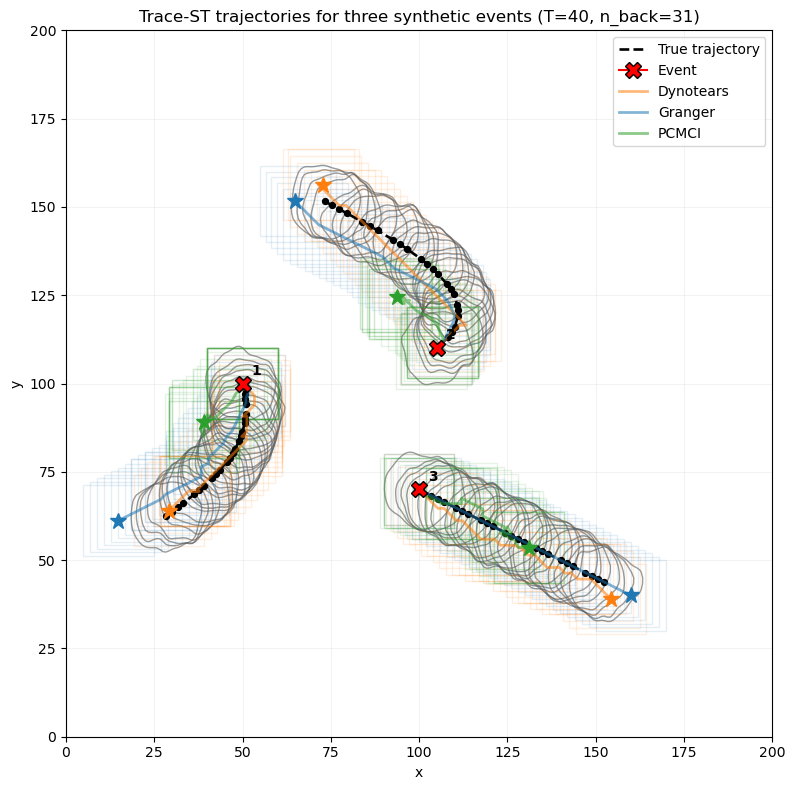

In [83]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


def add_boxes(ax, centers, box_size, color, alpha=0.14, lw=1.1, zorder=2):
    half = box_size / 2.0
    for yc, xc in centers:
        rect = Rectangle(
            (xc - half, yc - half),
            box_size,
            box_size,
            fill=False,
            edgecolor=color,
            linewidth=lw,
            alpha=alpha,
            zorder=zorder,
        )
        ax.add_patch(rect)


# ---------------------------------------
# plotting setup
# ---------------------------------------
extent = [0, 200, 0, 200]
fig, ax = plt.subplots(figsize=(10.5, 8))

# how many truth contours to show
n_back = max(
    max(len(track_results[name]["dynotears"]["centers"]) for name in track_results),
    max(len(track_results[name]["granger"]["centers"]) for name in track_results),
    max(len(track_results[name]["pcmci"]["centers"]) for name in track_results),
)

# number of truth snapshots to draw for visualization
n_truth_plot = min(24, n_back)
truth_idx = np.linspace(T - n_back, T - 1, n_truth_plot, dtype=int)
truth_idx = np.unique(truth_idx)

# ---------------------------------------
# 1) plot contours of A (combined field)
# ---------------------------------------
for t in truth_idx:
    ax.contour(
        xs,
        ys,
        A[t],
        levels=[0.6],
        colors=["0.35"],
        linewidths=1.0,
        alpha=0.6,
        zorder=1,
    )

# ---------------------------------------
# 2) true trajectories + event markers
# ---------------------------------------
for k, spec in enumerate(track_specs, start=1):
    truth = np.asarray(spec["centers"], dtype=float)
    event_y, event_x = spec["event"]

    ax.plot(
        truth[truth_idx, 1],
        truth[truth_idx, 0],
        "--",
        color="black",
        linewidth=1.9,
        zorder=4,
        label="True trajectory" if k == 1 else None,
    )

    ax.scatter(
        truth[truth_idx, 1],
        truth[truth_idx, 0],
        s=18,
        color="black",
        zorder=5,
    )

    ax.plot(
        event_x,
        event_y,
        marker="X",
        markersize=12,
        color="red",
        markeredgecolor="black",
        zorder=10,
        label="Event" if k == 1 else None,
    )

    ax.text(
        event_x + 2.5,
        event_y + 2.5,
        f"{k}",
        fontsize=10,
        weight="bold",
        color="black",
        zorder=11,
    )

# ---------------------------------------
# 3) recovered trajectories from the 3 methods
# ---------------------------------------
method_specs = [
    ("dynotears", "Dynotears", "tab:orange"),
    ("granger",   "Granger",   "tab:blue"),
    ("pcmci",     "PCMCI",     "tab:green"),
]

shown_labels = set()

for spec in track_specs:
    result_i = track_results[spec["name"]]

    for method_key, method_label, color in method_specs:
        centers = np.asarray(result_i[method_key]["centers"], dtype=float)

        add_boxes(
            ax,
            centers,
            box_size=box_size,
            color=color,
            alpha=0.12,
            lw=1.0,
            zorder=2,
        )

        ax.plot(
            centers[:, 1],
            centers[:, 0],
            "-",
            color=color,
            linewidth=2.0,
            alpha=0.55,
            zorder=6,
            label=method_label if method_label not in shown_labels else None,
        )

        ax.plot(
            centers[0, 1],
            centers[0, 0],
            marker="s",
            markersize=7,
            color=color,
            zorder=7,
        )

        ax.plot(
            centers[-1, 1],
            centers[-1, 0],
            marker="*",
            markersize=12,
            color=color,
            zorder=8,
        )

        shown_labels.add(method_label)

# ---------------------------------------
# 4) formatting
# ---------------------------------------
ax.set_xlim(extent[0], extent[1])
ax.set_ylim(extent[2], extent[3])
ax.set_aspect("equal")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(True, alpha=0.22, linewidth=0.5)

ax.set_title(
    f"Trace-ST trajectories for three synthetic events (T={T}, n_back={n_back})",
    fontsize=12
)

ax.legend(loc="upper right", frameon=True)
plt.tight_layout()
plt.show()

# Hyperparameter optimization

In [53]:
import copy
from multiprocessing import Pool
from pathlib import Path

import numpy as np
import pandas as pd

OUTDIR = Path("/glade/derecho/scratch/jhayron/DataCaStLeBTs/ResultsSynthetic")
OUTDIR.mkdir(parents=True, exist_ok=True)

SEARCH_SEED = 11
rng_search = np.random.default_rng(SEARCH_SEED)

In [54]:
SEARCH_SPACE_SHARED = dict(
    timewindow=["2d","3d", "4d"],
    box_size=[15,20,25,30],
    radius=[2,3],
    eps_dbscan=[0.05,0.1,0.15,0.2,0.25],
    min_samples_dbscan=[2],
    score_mode=["sum","mean"],
    winner_summary=["mean"],
    alpha=[0,0.5,1,2,4,8,16,32,64],
    prefer_sign=["both"],
    prob_rule=["linear", "softmax"],
    beta_softmax=[0,0.5,1,2,4,8,16,32,64],
)

In [55]:
def sample_shared_params(rng):
    out = {}
    for k, v in SEARCH_SPACE_SHARED.items():
        x = rng.choice(v)
        if isinstance(x, np.str_):
            x = str(x)
        elif isinstance(x, np.generic):
            x = x.item()
        out[k] = x
    return out

def sample_granger_trial(rng):
    return {
        "lambda_a": float(10 ** rng.uniform(-3, -0.5)),
        # "lambda_a": float(rng.uniform(0, 1)),
        # "lambda_a": float(rng.choice([0.001,0.005,0.01,0.05,0.1,0.25,0.5,0.75,1])),
        "l1_ratio": float(10 ** rng.uniform(-4, 0)),
        # "l1_ratio": float(rng.uniform(0, 1)),
        # "l1_ratio": float(rng.choice([0.001,0.005,0.01,0.05,0.1,0.25,0.5,0.75,1])),
        "dependence_threshold": float(rng.choice([1e-7])),
        "max_iter": int(rng.choice([100000])),
        "fit_intercept": bool(rng.choice([False])),
        "refit_ridge": bool(rng.choice([False])),
        "ridge_alpha": float(rng.choice([1e-2])),
    }

def sample_pcmci_trial(rng):
    cond_name = str(rng.choice(["parcorr", "robustparcorr"]))
    fdr = rng.choice([None, "bh"])
    if isinstance(fdr, np.str_):
        fdr = str(fdr)

    return {
        "pc_alpha": float(rng.choice([1e-4, 1e-3, 1e-2, 1e-1])),
        "graph_p_threshold": float(rng.choice([1e-4, 1e-3, 1e-2, 1e-1])),
        "cond_ind_test_name": cond_name,
        "fdr_method": fdr,
    }

def sample_dynotears_trial(rng):
    return {
        "lambda_a": float(10 ** rng.uniform(-3, -0.5)),
        "max_iter": int(rng.choice([100, 300, 500, 1000, 3000])),
        "dependence_threshold": float(rng.choice([1e-4, 1e-3, 1e-2, 1e-1])),
    }

In [56]:
def build_jobs(n_per_method=10, seed=123):
    rng = np.random.default_rng(seed)
    jobs = []

    for i in range(n_per_method):
        shared = sample_shared_params(rng)
        jobs.append(("granger", i, {**shared, **sample_granger_trial(rng)}))

    for i in range(n_per_method):
        shared = sample_shared_params(rng)
        jobs.append(("pcmci", i, {**shared, **sample_pcmci_trial(rng)}))

    for i in range(n_per_method):
        shared = sample_shared_params(rng)
        jobs.append(("dynotears", i, {**shared, **sample_dynotears_trial(rng)}))

    return jobs


jobs_test = build_jobs(n_per_method=100, seed=SEARCH_SEED)
print("Total jobs:", len(jobs_test))
print(jobs_test[:3])

Total jobs: 300
[('granger', 0, {'timewindow': '2d', 'box_size': 15, 'radius': 3, 'eps_dbscan': 0.15, 'min_samples_dbscan': 2, 'score_mode': 'mean', 'winner_summary': 'mean', 'alpha': 8.0, 'prefer_sign': 'both', 'prob_rule': 'softmax', 'beta_softmax': 0.0, 'lambda_a': 0.0023432315783503467, 'l1_ratio': 0.5162310133018718, 'dependence_threshold': 1e-07, 'max_iter': 100000, 'fit_intercept': False, 'refit_ridge': False, 'ridge_alpha': 0.01}), ('granger', 1, {'timewindow': '3d', 'box_size': 15, 'radius': 3, 'eps_dbscan': 0.05, 'min_samples_dbscan': 2, 'score_mode': 'mean', 'winner_summary': 'mean', 'alpha': 64.0, 'prefer_sign': 'both', 'prob_rule': 'softmax', 'beta_softmax': 8.0, 'lambda_a': 0.008365324826408867, 'l1_ratio': 0.011106061836457801, 'dependence_threshold': 1e-07, 'max_iter': 100000, 'fit_intercept': False, 'refit_ridge': False, 'ridge_alpha': 0.01}), ('granger', 2, {'timewindow': '3d', 'box_size': 25, 'radius': 3, 'eps_dbscan': 0.1, 'min_samples_dbscan': 2, 'score_mode': 'mea

In [57]:
def build_cond_ind_test(name):
    if name == "parcorr":
        return ParCorr()
    elif name == "robustparcorr":
        return RobustParCorr()
    elif name == "gpdc":
        return GPDC()
    elif name == "cmiknn":
        return CMIknn()
    else:
        raise ValueError(f"Unknown cond_ind_test_name: {name}")

In [58]:
import time

def evaluate_job(job):
    method, trial_id, trial = job
    t0 = time.perf_counter()

    try:
        if method == "granger":
            pbase = copy.deepcopy(params_elasticnet)
        elif method == "pcmci":
            pbase = copy.deepcopy(params_pcmci)
        elif method == "dynotears":
            pbase = copy.deepcopy(params_dynotears)
        else:
            raise ValueError(method)

        # ---------- shared params ----------
        for k in [
            "timewindow", "box_size", "radius", "eps_dbscan",
            "min_samples_dbscan", "score_mode", "winner_summary",
            "alpha", "prefer_sign"
        ]:
            pbase[k] = trial[k]

        pbase["n_steps_time"] = 30
        pbase["child_of_interest"] = 1
        pbase["montecarlo"] = False
        pbase["snap_to_grid"] = False
        pbase["averaging_winners"] = True
        pbase["verbose"] = False

        # ---------- method-specific ----------
        if method == "granger":
            pbase["cd_kwargs"]["lambda_a"] = trial["lambda_a"]
            pbase["cd_kwargs"]["l1_ratio"] = trial["l1_ratio"]
            pbase["cd_kwargs"]["dependence_threshold"] = trial["dependence_threshold"]
            pbase["cd_kwargs"]["max_iter"] = trial["max_iter"]
            pbase["cd_kwargs"]["fit_intercept"] = trial["fit_intercept"]
            pbase["cd_kwargs"]["refit_ridge"] = trial["refit_ridge"]
            pbase["cd_kwargs"]["ridge_alpha"] = trial["ridge_alpha"]

        elif method == "pcmci":
            pbase["cd_kwargs"]["pc_alpha"] = trial["pc_alpha"]
            pbase["cd_kwargs"]["graph_p_threshold"] = trial["graph_p_threshold"]
            pbase["cd_kwargs"]["fdr_method"] = trial["fdr_method"]
            pbase["cd_kwargs"]["cond_ind_test"] = build_cond_ind_test(trial["cond_ind_test_name"])

        elif method == "dynotears":
            pbase["cd_kwargs"]["lambda_a"] = trial["lambda_a"]
            pbase["cd_kwargs"]["max_iter"] = trial["max_iter"]
            pbase["cd_kwargs"]["dependence_threshold"] = trial["dependence_threshold"]

        # ---------- outputs ----------
        track_rows = []
        traj_rows = []
        target_len = int(pbase["n_steps_time"]) + 1

        mean_distances = []
        origin_distances = []
        event_distances = []
        raw_lens = []
        failed_flags = []
        path_lengths = []
        net_displacements = []
        mean_steps = []
        stagnant_fracs = []
        parent2_fracs = []

        for i, spec in enumerate(track_specs, start=1):
            event_y, event_x = spec["event"]

            p = copy.deepcopy(pbase)
            p["starting_lat"] = float(event_y)
            p["starting_lon"] = float(event_x)

            centers_run, parents_run, _ = run_one_track(full_data_run, p, date_end)

            centers_raw = np.asarray(centers_run, dtype=float)
            parents_raw = np.asarray(parents_run, dtype=int)

            pred = centers_raw[::-1].copy()
            parents = parents_raw[::-1].copy()

            truth_idx = np.linspace(T - target_len, T - 1, target_len, dtype=int)
            truth = np.asarray(spec["centers"], dtype=float)[truth_idx]

            raw_len = len(pred)
            failed = int(raw_len == 0)

            traj_rows.append({
                "method": method,
                "trial_id": trial_id,
                "track_name": spec["name"],
                "track_idx": i,
                "event_y": float(event_y),
                "event_x": float(event_x),
                "centers_raw": centers_raw.tolist(),
                "parents_raw": parents_raw.tolist(),
                "elapsed_sec": time.perf_counter() - t0,
                **trial,
            })

            if raw_len == 0:
                row = {
                    "method": method,
                    "trial_id": trial_id,
                    "track_name": spec["name"],
                    "track_idx": i,
                    "event_y": event_y,
                    "event_x": event_x,
                    "raw_len": 0,
                    "failed": 1,
                    "mean_distance": np.nan,
                    "origin_distance": np.nan,
                    "event_distance": np.nan,
                    "path_length": np.nan,
                    "net_displacement": np.nan,
                    "mean_step": np.nan,
                    "stagnant_frac": np.nan,
                    "parent2_frac": np.nan,
                    "elapsed_sec": time.perf_counter() - t0,
                    **trial,
                }
                track_rows.append(row)

                raw_lens.append(0)
                failed_flags.append(1)
                mean_distances.append(np.nan)
                origin_distances.append(np.nan)
                event_distances.append(np.nan)
                path_lengths.append(np.nan)
                net_displacements.append(np.nan)
                mean_steps.append(np.nan)
                stagnant_fracs.append(np.nan)
                parent2_fracs.append(np.nan)
                continue

            # pad/truncate to common length for truth comparison
            if len(pred) < target_len:
                pred = np.vstack([
                    pred,
                    np.repeat(pred[-1:, :], target_len - len(pred), axis=0)
                ])
                parents = np.concatenate([
                    parents,
                    np.repeat(parents[-1:], target_len - len(parents), axis=0)
                ])
            else:
                pred = pred[:target_len]
                parents = parents[:target_len]

            dy = pred[:, 0] - truth[:, 0]
            dx = pred[:, 1] - truth[:, 1]
            pointwise_dist = np.sqrt(dx**2 + dy**2)

            origin_distance = float(pointwise_dist[0])   # t-30
            event_distance = float(pointwise_dist[-1])   # t0

            steps = np.sqrt(np.sum(np.diff(pred, axis=0)**2, axis=1))
            path_length = float(np.sum(steps))
            net_displacement = float(np.sqrt(np.sum((pred[-1] - pred[0]) ** 2)))
            mean_step = float(np.mean(steps)) if len(steps) > 0 else 0.0
            stagnant_frac = float(np.mean(steps < 1e-6)) if len(steps) > 0 else 1.0
            parent2_frac = float(np.mean(parents == 2))

            row = {
                "method": method,
                "trial_id": trial_id,
                "track_name": spec["name"],
                "track_idx": i,
                "event_y": event_y,
                "event_x": event_x,
                "raw_len": raw_len,
                "failed": failed,
                "mean_distance": float(np.mean(pointwise_dist)),
                "origin_distance": origin_distance,
                "event_distance": event_distance,
                "path_length": path_length,
                "net_displacement": net_displacement,
                "mean_step": mean_step,
                "stagnant_frac": stagnant_frac,
                "parent2_frac": parent2_frac,
                "elapsed_sec": time.perf_counter() - t0,
                **trial,
            }
            track_rows.append(row)

            raw_lens.append(raw_len)
            failed_flags.append(failed)
            mean_distances.append(float(np.mean(pointwise_dist)))
            origin_distances.append(origin_distance)
            event_distances.append(event_distance)
            path_lengths.append(path_length)
            net_displacements.append(net_displacement)
            mean_steps.append(mean_step)
            stagnant_fracs.append(stagnant_frac)
            parent2_fracs.append(parent2_frac)

        # ---------- one summary row per trial ----------
        summary_row = {
            "method": method,
            "trial_id": trial_id,
            "n_tracks": len(track_specs),
            "n_failed": int(np.nansum(failed_flags)),
            "mean_raw_len": float(np.nanmean(raw_lens)),
            "min_raw_len": float(np.nanmin(raw_lens)),
            "mean_distance": float(np.nanmean(mean_distances)),
            "max_distance": float(np.nanmax(mean_distances)),
            "mean_origin_distance": float(np.nanmean(origin_distances)),
            "mean_event_distance": float(np.nanmean(event_distances)),
            "mean_path_length": float(np.nanmean(path_lengths)),
            "mean_net_displacement": float(np.nanmean(net_displacements)),
            "mean_step": float(np.nanmean(mean_steps)),
            "mean_stagnant_frac": float(np.nanmean(stagnant_fracs)),
            "mean_parent2_frac": float(np.nanmean(parent2_fracs)),
            "elapsed_sec": time.perf_counter() - t0,
            **trial,
        }

        for idx in range(len(track_specs)):
            j = idx + 1
            summary_row[f"track{j}_raw_len"] = raw_lens[idx]
            summary_row[f"track{j}_failed"] = failed_flags[idx]
            summary_row[f"track{j}_mean_distance"] = mean_distances[idx]
            summary_row[f"track{j}_origin_distance"] = origin_distances[idx]
            summary_row[f"track{j}_event_distance"] = event_distances[idx]
            summary_row[f"track{j}_path_length"] = path_lengths[idx]
            summary_row[f"track{j}_net_displacement"] = net_displacements[idx]
            summary_row[f"track{j}_mean_step"] = mean_steps[idx]
            summary_row[f"track{j}_stagnant_frac"] = stagnant_fracs[idx]
            summary_row[f"track{j}_parent2_frac"] = parent2_fracs[idx]

        return {
            "track_rows": track_rows,
            "summary_row": summary_row,
            "traj_rows": traj_rows,
        }

    except Exception as e:
        elapsed = time.perf_counter() - t0
        return {
            "track_rows": [{
                "method": method,
                "trial_id": trial_id,
                "track_name": "ERROR",
                "track_idx": -1,
                "failed": 1,
                "error_msg": str(e),
                "elapsed_sec": elapsed,
                **trial,
            }],
            "summary_row": {
                "method": method,
                "trial_id": trial_id,
                "n_tracks": len(track_specs),
                "n_failed": len(track_specs),
                "error_msg": str(e),
                "elapsed_sec": elapsed,
                **trial,
            },
            "traj_rows": [],
        }

In [59]:
NPROC = 8

results = []
total = len(jobs_test)

with Pool(processes=NPROC) as pool:
    for i, res in enumerate(pool.imap_unordered(evaluate_job, jobs_test), 1):
        results.append(res)
        if i % 10 == 0 or i == total:
            print(f"{i}/{total} jobs completed")

10/300 jobs completed
20/300 jobs completed
30/300 jobs completed
40/300 jobs completed
50/300 jobs completed
60/300 jobs completed
70/300 jobs completed
80/300 jobs completed
90/300 jobs completed
100/300 jobs completed
110/300 jobs completed
120/300 jobs completed
130/300 jobs completed
140/300 jobs completed
150/300 jobs completed
160/300 jobs completed
170/300 jobs completed
180/300 jobs completed
190/300 jobs completed
200/300 jobs completed
210/300 jobs completed
220/300 jobs completed
230/300 jobs completed
240/300 jobs completed
250/300 jobs completed
260/300 jobs completed
270/300 jobs completed
280/300 jobs completed
290/300 jobs completed
300/300 jobs completed


In [60]:
track_rows = []
summary_rows = []
traj_rows = []

for res in results:
    track_rows.extend(res["track_rows"])
    summary_rows.append(res["summary_row"])
    traj_rows.extend(res["traj_rows"])

df_search_long = pd.DataFrame(track_rows)
df_search_trial = pd.DataFrame(summary_rows)
df_search_traj = pd.DataFrame(traj_rows)

print("df_search_long:", df_search_long.shape)
print("df_search_trial:", df_search_trial.shape)
print("df_search_traj:", df_search_traj.shape)

df_search_long.head()

df_search_long: (900, 39)
df_search_trial: (300, 68)
df_search_traj: (900, 31)


,method,trial_id,track_name,track_idx,event_y,event_x,raw_len,failed,mean_distance,origin_distance,...,l1_ratio,dependence_threshold,max_iter,fit_intercept,refit_ridge,ridge_alpha,pc_alpha,graph_p_threshold,cond_ind_test_name,fdr_method
0,granger,0,Track 1,1,100.0,50.0,31,0,13.382662,27.642235,...,0.516231,1.000000e-07,100000.0,False,False,0.01,NaN,NaN,NaN,NaN
1,granger,0,Track 2,2,110.0,105.0,31,0,21.580115,51.198990,...,0.516231,1.000000e-07,100000.0,False,False,0.01,NaN,NaN,NaN,NaN
2,granger,0,Track 3,3,70.0,100.0,31,0,15.835144,41.313200,...,0.516231,1.000000e-07,100000.0,False,False,0.01,NaN,NaN,NaN,NaN
3,granger,1,Track 1,1,100.0,50.0,31,0,9.842993,27.034150,...,0.011106,1.000000e-07,100000.0,False,False,0.01,NaN,NaN,NaN,NaN
4,granger,1,Track 2,2,110.0,105.0,31,0,20.654050,51.949073,...,0.011106,1.000000e-07,100000.0,False,False,0.01,NaN,NaN,NaN,NaN


In [61]:
tag = "univariate_search_test_n100_all"

path_long = OUTDIR / f"{tag}_long.csv"
path_trial = OUTDIR / f"{tag}_trial.csv"
path_traj = OUTDIR / f"{tag}_traj.pkl"

df_search_long.to_csv(path_long, index=False)
df_search_trial.to_csv(path_trial, index=False)
df_search_traj.to_pickle(path_traj)

print("Saved long  ->", path_long)
print("Saved trial ->", path_trial)
print("Saved traj  ->", path_traj)

Saved long  -> /glade/derecho/scratch/jhayron/DataCaStLeBTs/ResultsSynthetic/univariate_search_test_n100_all_long.csv
Saved trial -> /glade/derecho/scratch/jhayron/DataCaStLeBTs/ResultsSynthetic/univariate_search_test_n100_all_trial.csv
Saved traj  -> /glade/derecho/scratch/jhayron/DataCaStLeBTs/ResultsSynthetic/univariate_search_test_n100_all_traj.pkl


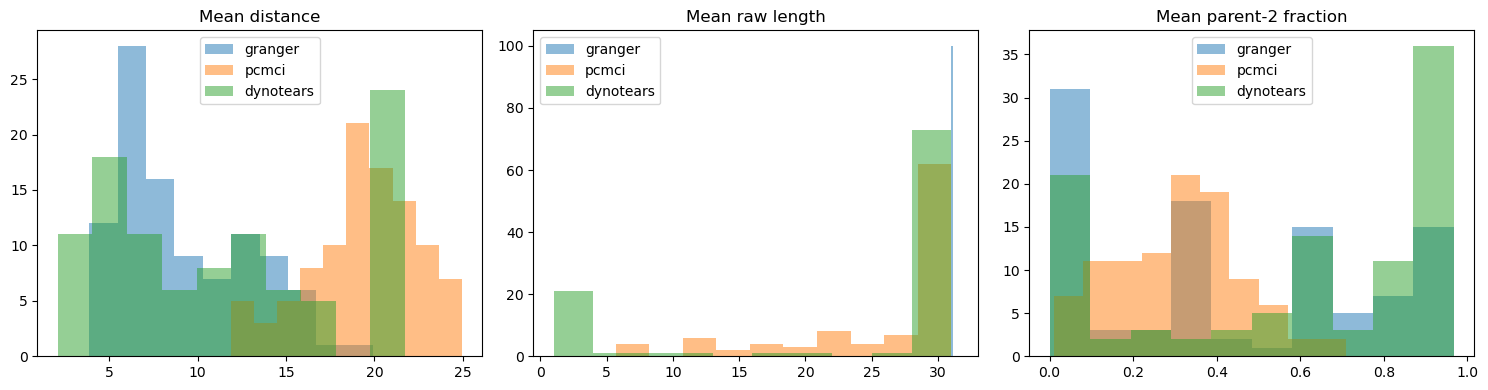

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for method in ["granger", "pcmci", "dynotears"]:
    sub = df_search_trial[df_search_trial["method"] == method]

    axes[0].hist(sub["mean_distance"].dropna(), bins=10, alpha=0.5, label=method)
    axes[1].hist(sub["mean_raw_len"].dropna(), bins=10, alpha=0.5, label=method)
    axes[2].hist(sub["mean_parent2_frac"].dropna(), bins=10, alpha=0.5, label=method)

axes[0].set_title("Mean distance")
axes[1].set_title("Mean raw length")
axes[2].set_title("Mean parent-2 fraction")

for ax in axes:
    ax.legend()

plt.tight_layout()
plt.show()

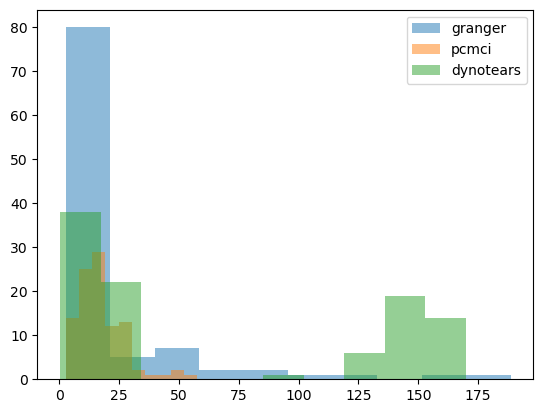

In [63]:
for method in ["granger", "pcmci", "dynotears"]:
    sub = df_search_trial[df_search_trial["method"] == method]

    plt.hist(sub["elapsed_sec"].dropna(), bins=10, alpha=0.5, label=method)

plt.legend()

In [64]:
df_search_trial.keys()

Index(['method', 'trial_id', 'n_tracks', 'n_failed', 'mean_raw_len',
       'min_raw_len', 'mean_distance', 'max_distance', 'mean_origin_distance',
       'mean_event_distance', 'mean_path_length', 'mean_net_displacement',
       'mean_step', 'mean_stagnant_frac', 'mean_parent2_frac', 'elapsed_sec',
       'timewindow', 'box_size', 'radius', 'eps_dbscan', 'min_samples_dbscan',
       'score_mode', 'winner_summary', 'alpha', 'prefer_sign', 'prob_rule',
       'beta_softmax', 'lambda_a', 'l1_ratio', 'dependence_threshold',
       'max_iter', 'fit_intercept', 'refit_ridge', 'ridge_alpha',
       'track1_raw_len', 'track1_failed', 'track1_mean_distance',
       'track1_origin_distance', 'track1_event_distance', 'track1_path_length',
       'track1_net_displacement', 'track1_mean_step', 'track1_stagnant_frac',
       'track1_parent2_frac', 'track2_raw_len', 'track2_failed',
       'track2_mean_distance', 'track2_origin_distance',
       'track2_event_distance', 'track2_path_length',
       

In [65]:
# keys_params = ['method','elapsed_sec',
#        'timewindow', 'box_size', 'radius', 'eps_dbscan', 'min_samples_dbscan',
#        'score_mode', 'winner_summary', 'alpha', 'prefer_sign', 'prob_rule',
#        'beta_softmax', 'lambda_a', 'l1_ratio', 'dependence_threshold',
#        'max_iter', 'fit_intercept', 'refit_ridge', 'ridge_alpha','pc_alpha', 'graph_p_threshold',
#        'cond_ind_test_name', 'fdr_method']

keys_params = ['method','elapsed_sec',
       'timewindow', 'box_size', 'radius', 'eps_dbscan', 'min_samples_dbscan',
       'score_mode', 'winner_summary', 'alpha', 'prefer_sign', 'prob_rule',
       'beta_softmax', 'lambda_a', 'l1_ratio', 'dependence_threshold',
       'max_iter', 'fit_intercept', 'refit_ridge', 'ridge_alpha']

In [66]:
df_search_trial[df_search_trial['elapsed_sec']>100][keys_params]

,method,elapsed_sec,timewindow,box_size,radius,eps_dbscan,min_samples_dbscan,score_mode,winner_summary,alpha,prefer_sign,prob_rule,beta_softmax,lambda_a,l1_ratio,dependence_threshold,max_iter,fit_intercept,refit_ridge,ridge_alpha
40,granger,103.063030,4d,25,2,0.10,2,mean,mean,64.0,both,softmax,0.5,0.001210,0.000635,1.000000e-07,100000.0,False,False,0.01
111,granger,161.302902,4d,25,2,0.25,2,sum,mean,2.0,both,softmax,32.0,0.001109,0.000129,1.000000e-07,100000.0,False,False,0.01
131,granger,116.482693,4d,20,3,0.05,2,sum,mean,8.0,both,linear,2.0,0.001530,0.001107,1.000000e-07,100000.0,False,False,0.01
148,granger,188.656568,4d,25,3,0.20,2,sum,mean,1.0,both,linear,4.0,0.001300,0.001417,1.000000e-07,100000.0,False,False,0.01
210,dynotears,135.579302,4d,15,3,0.25,2,sum,mean,0.5,both,softmax,2.0,0.022628,NaN,1.000000e-03,1000.0,NaN,NaN,NaN
211,dynotears,157.194583,2d,30,3,0.10,2,mean,mean,16.0,both,softmax,8.0,0.027413,NaN,1.000000e-04,100.0,NaN,NaN,NaN
212,dynotears,160.982681,3d,30,3,0.10,2,mean,mean,4.0,both,linear,1.0,0.001430,NaN,1.000000e-02,100.0,NaN,NaN,NaN
213,dynotears,142.997178,4d,20,3,0.15,2,sum,mean,8.0,both,linear,1.0,0.002080,NaN,1.000000e-03,100.0,NaN,NaN,NaN
214,dynotears,153.352548,2d,30,3,0.20,2,mean,mean,16.0,both,softmax,16.0,0.014358,NaN,1.000000e-04,500.0,NaN,NaN,NaN
217,dynotears,135.381145,2d,15,3,0.05,2,sum,mean,32.0,both,softmax,0.0,0.037895,NaN,1.000000e-02,500.0,NaN,NaN,NaN


In [67]:
df_search_long.head()

,method,trial_id,track_name,track_idx,event_y,event_x,raw_len,failed,mean_distance,origin_distance,...,l1_ratio,dependence_threshold,max_iter,fit_intercept,refit_ridge,ridge_alpha,pc_alpha,graph_p_threshold,cond_ind_test_name,fdr_method
0,granger,0,Track 1,1,100.0,50.0,31,0,13.382662,27.642235,...,0.516231,1.000000e-07,100000.0,False,False,0.01,NaN,NaN,NaN,NaN
1,granger,0,Track 2,2,110.0,105.0,31,0,21.580115,51.198990,...,0.516231,1.000000e-07,100000.0,False,False,0.01,NaN,NaN,NaN,NaN
2,granger,0,Track 3,3,70.0,100.0,31,0,15.835144,41.313200,...,0.516231,1.000000e-07,100000.0,False,False,0.01,NaN,NaN,NaN,NaN
3,granger,1,Track 1,1,100.0,50.0,31,0,9.842993,27.034150,...,0.011106,1.000000e-07,100000.0,False,False,0.01,NaN,NaN,NaN,NaN
4,granger,1,Track 2,2,110.0,105.0,31,0,20.654050,51.949073,...,0.011106,1.000000e-07,100000.0,False,False,0.01,NaN,NaN,NaN,NaN


In [68]:
df_search_trial.head()

,method,trial_id,n_tracks,n_failed,mean_raw_len,min_raw_len,mean_distance,max_distance,mean_origin_distance,mean_event_distance,...,track3_event_distance,track3_path_length,track3_net_displacement,track3_mean_step,track3_stagnant_frac,track3_parent2_frac,pc_alpha,graph_p_threshold,cond_ind_test_name,fdr_method
0,granger,0,3,0,31.0,31.0,16.932640,21.580115,40.051475,0.0,...,0.0,23.722852,17.196284,0.790762,0.666667,0.838710,NaN,NaN,NaN,NaN
1,granger,1,3,0,31.0,31.0,16.200169,20.654050,41.237022,0.0,...,0.0,23.426102,14.212670,0.780870,0.766667,0.806452,NaN,NaN,NaN,NaN
2,granger,2,3,0,31.0,31.0,14.366414,21.205164,31.615100,0.0,...,0.0,72.114996,71.106676,2.403833,0.266667,0.000000,NaN,NaN,NaN,NaN
3,granger,4,3,0,31.0,31.0,12.530898,18.912251,27.834653,0.0,...,0.0,54.041597,53.476743,1.801387,0.366667,0.387097,NaN,NaN,NaN,NaN
4,granger,10,3,0,31.0,31.0,6.089491,11.871926,11.625645,0.0,...,0.0,61.025128,55.391462,2.034171,0.000000,0.000000,NaN,NaN,NaN,NaN


In [69]:
df_search_traj.head()

,method,trial_id,track_name,track_idx,event_y,event_x,centers_raw,parents_raw,elapsed_sec,timewindow,...,l1_ratio,dependence_threshold,max_iter,fit_intercept,refit_ridge,ridge_alpha,pc_alpha,graph_p_threshold,cond_ind_test_name,fdr_method
0,granger,0,Track 1,1,100.0,50.0,"[[100.0, 50.0], [98.0, 53.0], [99.0, 53.0], [1...","[1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...",0.991105,2d,...,0.516231,1.000000e-07,100000.0,False,False,0.01,NaN,NaN,NaN,NaN
1,granger,0,Track 2,2,110.0,105.0,"[[110.0, 105.0], [113.0, 108.0], [113.0, 108.0...","[1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...",1.847579,2d,...,0.516231,1.000000e-07,100000.0,False,False,0.01,NaN,NaN,NaN,NaN
2,granger,0,Track 3,3,70.0,100.0,"[[70.0, 100.0], [68.88173843607552, 102.996827...","[1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...",2.865002,2d,...,0.516231,1.000000e-07,100000.0,False,False,0.01,NaN,NaN,NaN,NaN
3,granger,1,Track 1,1,100.0,50.0,"[[100.0, 50.0], [97.0, 47.0], [97.0, 47.0], [9...","[1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...",4.113318,3d,...,0.011106,1.000000e-07,100000.0,False,False,0.01,NaN,NaN,NaN,NaN
4,granger,1,Track 2,2,110.0,105.0,"[[110.0, 105.0], [112.0, 108.0], [115.0, 109.0...","[1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...",6.662339,3d,...,0.011106,1.000000e-07,100000.0,False,False,0.01,NaN,NaN,NaN,NaN


In [70]:
import ast
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


def add_boxes(ax, centers, box_size, color, alpha=0.14, lw=1.1, zorder=2):
    half = box_size / 2.0
    for yc, xc in centers:
        rect = Rectangle(
            (xc - half, yc - half),
            box_size,
            box_size,
            fill=False,
            edgecolor=color,
            linewidth=lw,
            alpha=alpha,
            zorder=zorder,
        )
        ax.add_patch(rect)


def _to_array(x):
    if isinstance(x, str):
        x = ast.literal_eval(x)
    return np.asarray(x, dtype=float)


def plot_trial_trajectories(
    trial_row,
    df_search_traj,
    track_specs,
    A,
    xs,
    ys,
    T,
    contour_level=0.6,
    extent=(0, 200, 0, 200),
    figsize=(10.5, 8),
    n_truth_plot=24,
    box_stride=2,
):
    """
    Plot the 3 synthetic truth trajectories and the recovered trajectories
    for one selected trial row from df_search_trial.

    Parameters
    ----------
    trial_row : pd.Series
        One row from df_search_trial, e.g. df_search_trial.iloc[0]
    df_search_traj : pd.DataFrame
        Trajectory archive with raw centers/parents
    track_specs : list of dict
        Synthetic truth definitions
    A : np.ndarray
        Parent field used for contours, shape (T, NY, NX)
    xs, ys : 1D arrays
        Grid coordinates
    T : int
        Number of timesteps
    n_truth_plot : int
        Number of truth snapshots/contours to display
    box_stride : int
        Plot every `box_stride`-th box to reduce clutter
    """
    method = trial_row["method"]
    trial_id = trial_row["trial_id"]
    box_size = float(trial_row["box_size"])

    sub = df_search_traj[
        (df_search_traj["method"] == method) &
        (df_search_traj["trial_id"] == trial_id)
    ].copy()

    if len(sub) == 0:
        raise ValueError(f"No trajectories found for method={method}, trial_id={trial_id}")

    # determine max recovered trajectory length across the 3 tracks
    lengths = []
    for _, r in sub.iterrows():
        centers = _to_array(r["centers_raw"])
        lengths.append(len(centers))
    n_back = max(lengths) if len(lengths) > 0 else 1

    truth_idx = np.linspace(T - n_back, T - 1, min(n_truth_plot, n_back), dtype=int)
    truth_idx = np.unique(truth_idx)

    fig, ax = plt.subplots(figsize=figsize)

    # --------------------------------------------------
    # 1) contours of A
    # --------------------------------------------------
    for t in truth_idx:
        ax.contour(
            xs,
            ys,
            A[t],
            levels=[contour_level],
            colors=["0.35"],
            linewidths=1.0,
            alpha=0.6,
            zorder=1,
        )

    # --------------------------------------------------
    # 2) true trajectories + event markers
    # --------------------------------------------------
    for k, spec in enumerate(track_specs, start=1):
        truth = np.asarray(spec["centers"], dtype=float)
        event_y, event_x = spec["event"]

        ax.plot(
            truth[truth_idx, 1],
            truth[truth_idx, 0],
            "--",
            color="black",
            linewidth=1.9,
            zorder=4,
            label="True trajectory" if k == 1 else None,
        )

        ax.scatter(
            truth[truth_idx, 1],
            truth[truth_idx, 0],
            s=18,
            color="black",
            zorder=5,
        )

        ax.plot(
            event_x,
            event_y,
            marker="X",
            markersize=12,
            color="red",
            markeredgecolor="black",
            zorder=10,
            label="Event" if k == 1 else None,
        )

        ax.text(
            event_x + 2.5,
            event_y + 2.5,
            f"{k}",
            fontsize=10,
            weight="bold",
            color="black",
            zorder=11,
        )

    # --------------------------------------------------
    # 3) recovered trajectories for this trial
    # --------------------------------------------------
    color = {
        "granger": "tab:blue",
        "pcmci": "tab:green",
        "dynotears": "tab:orange",
    }.get(method, "tab:purple")

    label_map = {
        "granger": "Granger",
        "pcmci": "PCMCI",
        "dynotears": "Dynotears",
    }
    method_label = label_map.get(method, str(method))

    shown_label = False

    for spec in track_specs:
        r = sub[sub["track_name"] == spec["name"]]
        if len(r) == 0:
            continue

        r = r.iloc[0]
        centers = _to_array(r["centers_raw"])

        centers_for_boxes = centers[::box_stride] if box_stride > 1 else centers

        add_boxes(
            ax,
            centers_for_boxes,
            box_size=box_size,
            color=color,
            alpha=0.14,
            lw=1.0,
            zorder=2,
        )

        ax.plot(
            centers[:, 1],
            centers[:, 0],
            "-",
            color=color,
            linewidth=2.0,
            alpha=0.55,
            zorder=6,
            label=method_label if not shown_label else None,
        )

        ax.plot(
            centers[0, 1],
            centers[0, 0],
            marker="s",
            markersize=7,
            color=color,
            zorder=7,
        )

        ax.plot(
            centers[-1, 1],
            centers[-1, 0],
            marker="*",
            markersize=12,
            color=color,
            zorder=8,
        )

        shown_label = True

    # --------------------------------------------------
    # 4) formatting
    # --------------------------------------------------
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True, alpha=0.22, linewidth=0.5)

    title = (
        f"TraCE-ST trajectories | method={method}, trial_id={trial_id}\n"
        f"box={trial_row['box_size']}, radius={trial_row['radius']}, "
        f"timewindow={trial_row['timewindow']}, eps={trial_row['eps_dbscan']}"
    )
    ax.set_title(title, fontsize=12)

    ax.legend(loc="upper right", frameon=True)
    plt.tight_layout()
    plt.show()

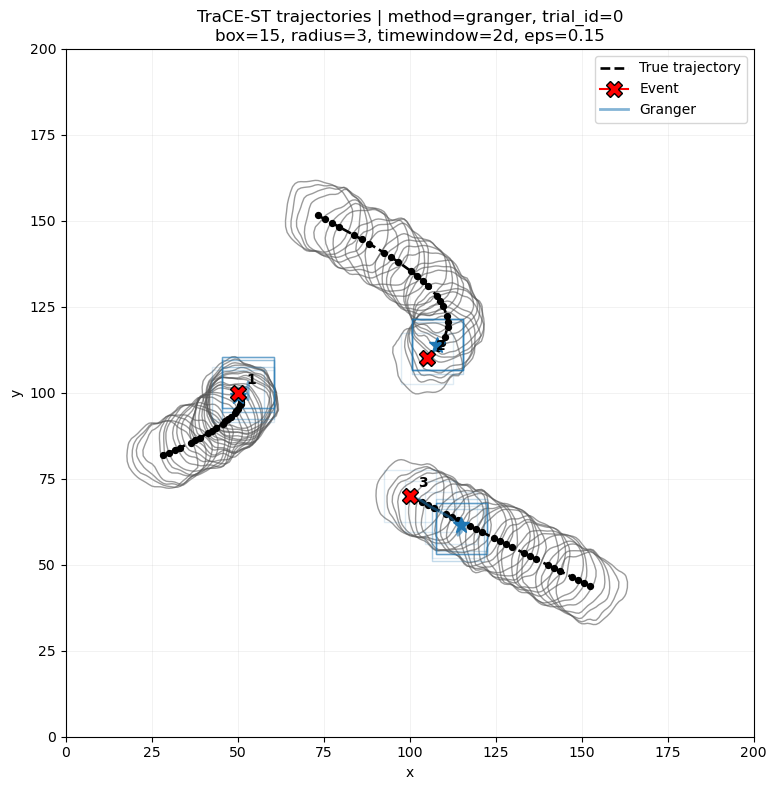

In [71]:
plot_trial_trajectories(
    trial_row=df_search_trial.iloc[0],
    df_search_traj=df_search_traj,
    track_specs=track_specs,
    A=A,
    xs=xs,
    ys=ys,
    T=T,
    n_truth_plot=24,
    box_stride=2,
)